# Bleeding-vs-ischaemic conflict — pairwise selection

Minimal algorithm. For each patient we compute a **conflict score** = how much
*shortening* the DAPT benefits them on **bleeding** plus how much it benefits them on the
**three ischaemic factors** (CV death, MI, stroke). Large-positive = shortening
helps on both axes (the **top-right / win–win** corner). Then: we draw **two random
patients**, keep the one with the higher conflict (= the one that makes most sense to
enrol in the study), and repeat.

Treatment coding (as in nb 06/07/10): `T=1` prolonged, `T=0` shortened.
`CATE_k = risk(prolonged) − risk(shortened)` = **benefit of shortening**
on endpoint `k` (>0 = shortening lowers that risk).

In [ ]:
import os 
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

perm = X.sample(frac=1, random_state=42).index

X = X.loc[perm].reset_index(drop=True)
y = y.loc[perm].reset_index(drop=True)

Xn = X.select_dtypes(include=[np.number])                       # same numeric matrix the CF was fit on (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()  # 1=prolonged
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
print('patients:', len(T), '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## Conflict score

Per-endpoint CATE from the **tuned causal forest** (`CausalForest_multioutput_tuned.joblib`
— the Optuna-tuned `CausalForestDML` fitted in nb 06), scored through `conflict_from_model`
(`online_learning_utils.py`) — the same helper nb 02 uses to re-score its online model, so
both notebooks build the conflict score identically. It RobustScales each endpoint's CATE to
this cohort, then combines the bleeding benefit with the ischaemic benefits weighted death
0.2 / mi 0.4 / stroke 0.4 (matching `components_from_origin` / `select_top_right`):

$$\text{conflict}(x) = z\big(\text{CATE}_{\text{bleed}}\big)
  + 0.2\,z(\text{CATE}_{\text{death}}) + 0.4\,z(\text{CATE}_{\text{mi}}) + 0.4\,z(\text{CATE}_{\text{stroke}}).$$

Large-positive = shortening helps a lot on **both** bleeding and ischaemia
= the **win–win** patient (top-right).

In [ ]:
# CATE from the tuned causal forest fitted in nb 06 (Optuna-tuned CausalForestDML).
# pipeline.effect = risk(prolonged) - risk(shortened) = benefit of shortening
# (>0 lowers that risk), exactly the sign convention this notebook uses.
CF_DIR     = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
MODEL_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'models',
                                           'CausalForest', 'CausalForest_multioutput_tuned.joblib'))
sys.path.insert(0, CF_DIR)                       # so joblib can unpickle CausalMultiOutputPipeline
cf = joblib.load(MODEL_PATH)

# Refit on this cohort, reusing nb 06's Optuna-tuned cf_params (they ride along on the
# pickled pipeline). Signature is fit(X, Y, T) -- Y second, T third.
# Y must be subset to nb 06's five TARGETS in their trained order: y_targets.parquet
# holds nine columns, and the extra four (barc2, barc3, barc35, revasc) would each grow
# a forest this notebook never reads.
CF_TARGETS     = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
CF_TARGET_COLS = ['cec_barc235_335d', 'cec_cvdeath_335d', 'cec_mi_335d',
                  'cec_stroke_335d', 'cec_bleed_335d']
cf.fit(Xn, y[CF_TARGET_COLS], T)

# Raw (unscaled) CATE per endpoint, kept around for the scatter plots below (natural risk
# units). The scaled/weighted conflict frame itself comes from conflict_from_model.
cate_all = cf.predict_cate(Xn.values)
C = {k: cate_all[:, CF_TARGETS.index(k)] for k in ENDPOINTS}

In [ ]:
from online_learning_utils import z, conflict_from_model, weighted_isch

ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}   # ischaemic weighting for conflict_from_model / components_from_origin

# Same helper nb 02 uses to re-score its online model: RobustScaler fit to this cohort,
# then conflict = z(bleed) + weighted ischaemic z-score (ISCH_WEIGHTS).
conflict = conflict_from_model(cf, Xn, ENDPOINTS, ISCH_WEIGHTS, CF_TARGETS)

isch = weighted_isch({k: z(conflict[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)

# sanity: mean bleed benefit >0 (shortening reduces bleeding), ischaemic <0 (they raise it)
print('mean CATE  ' + '  '.join(f'{k}={C[k].mean():+.4f}' for k in ENDPOINTS))
print('conflict range: %.2f .. %.2f' % (conflict['conflict'].min(), conflict['conflict'].max()))

## Pairwise selection

One-round knockout: draw `N_SELECT` candidates, pair them one-vs-one in disjoint pairs,
and keep only the winner of each pair — the better half (`N_SELECT // 2` patients).

In [ ]:
from online_learning_utils import components_from_origin
# duel_by_angle stays here: its Q1 tie-break (vector magnitude) is specific to this notebook.
# components_from_origin / duel_by_conflict now live in online_learning_utils.

def duel_by_angle(i, j):
    x1, y1 = components_from_origin(i, conflict, ISCH_WEIGHTS)
    x2, y2 = components_from_origin(j, conflict, ISCH_WEIGHTS)

    a1 = np.degrees(np.arctan2(y1, x1))
    a2 = np.degrees(np.arctan2(y2, x2))

    # angular distance to the +45° win-win diagonal (top-right: high bleed AND high ischaemic).
    # smaller = the vector points more squarely at the win-win corner.
    d1 = abs((a1 - 45 + 180) % 360 - 180)
    d2 = abs((a2 - 45 + 180) % 360 - 180)

    if (x1 > 0 and y1 > 0) and (x2 > 0 and y2 > 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 > m2 else j            # both win-win: keep the one further out

    if (x1 < 0 and y1 < 0) and (x2 < 0 and y2 < 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 < m2 else j            # both anti-win-win: keep the less-bad (closer to origin)

    return i if d1 < d2 else j                # else: keep the one nearest the +45° win-win diagonal

In [ ]:
def select_pairwise(n, rng):
    """One-round knockout: draw n candidates, pair them one-vs-one in disjoint pairs,
    and keep only the winner of each pair — the better half (returns n // 2 patients)."""
    cand = rng.permutation(len(conflict))[:n]
    return np.array([duel_by_angle(i, j) for i, j in zip(cand[::2], cand[1::2])])

N_SELECT = 3000               # candidates drawn; the better half (N_SELECT // 2) is kept
rng = np.random.default_rng(0)
sel = select_pairwise(N_SELECT, rng)
rnd = rng.choice(len(conflict), size=len(sel), replace=False)   # baseline: same many, at random

print(f'selected {len(sel)} of {N_SELECT} candidates')
print(f'mean conflict  selected={conflict["conflict"].iloc[sel].mean():+.3f}   random={conflict["conflict"].iloc[rnd].mean():+.3f}')
for k in ENDPOINTS:
    print(f'  event rate {k:7s}  selected={y[ENDPOINTS[k]].to_numpy()[sel].mean():.3f}'
          f'   random={y[ENDPOINTS[k]].to_numpy()[rnd].mean():.3f}')

selected 1500 of 3000 candidates
mean conflict  selected=+0.613   random=+0.012
  event rate bleed    selected=0.103   random=0.113
  event rate death    selected=0.019   random=0.021
  event rate mi       selected=0.020   random=0.025
  event rate stroke   selected=0.008   random=0.007


## What it selects

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(conflict['conflict'], bins=50, color='lightgrey', label='all')
ax[0].hist(conflict['conflict'].iloc[sel], bins=50, color='crimson', alpha=0.8, label='selected')
ax[0].set(xlabel='conflict score', ylabel='patients', title='Conflict distribution')
ax[0].legend()

ax[1].scatter(C['bleed'], isch, s=8, color='lightgrey', label='all')
ax[1].scatter(C['bleed'][sel], isch[sel], s=12, color='crimson', label='selected')
ax[1].axhline(0, color='k', lw=.8, alpha=.5); ax[1].axvline(0, color='k', lw=.8, alpha=.5)
ax[1].set(xlabel='bleeding benefit (shortening)', ylabel='weighted ischaemic benefit (shortening)',
          title='Trade-off plane — top-right = win–win (selected)')
ax[1].legend()
plt.tight_layout(); plt.show()

# the first patients to enrol, ordered by conflict
top = conflict["conflict"].nlargest(10)

print("Top-10 by conflict:")
for i, score in top.items():
    print(
        f"{i:5d}   "
        f"conflict={score:+.3f}   "
        f"bleed={C['bleed'][i]:+.3f}   "
        f"isch_mean={isch[i]:+.3f}"
    )

**In short:** the selected patients have a much higher mean conflict than random and
cluster in the top-right of the plane (shortening helps **both** bleeding and
ischaemia) — the clearest win–win patients, hence the most sensible to enrol first.

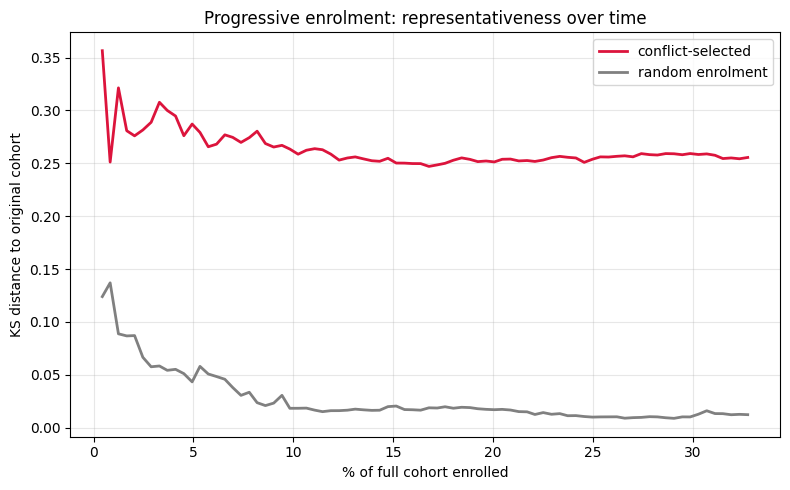

final: 33% of cohort taken   KS conflict=0.255   KS random=0.012


In [ ]:
# --- Progressive enrolment: % of the cohort taken  vs  KS distance to the original ---
# We enrol patients "mano a mano"; at each step we record how much of the full cohort we
# have taken (top panel) and the KS distance between the conflict score gathered so far
# and the ORIGINAL full-cohort distribution (bottom panel). KS = 0 -> indistinguishable.

def ks(a, b):
    """Two-sample Kolmogorov-Smirnov distance: the largest gap between the two ECDFs."""
    grid = np.sort(np.concatenate([a, b]))
    ca = np.searchsorted(np.sort(a), grid, side='right') / len(a)
    cb = np.searchsorted(np.sort(b), grid, side='right') / len(b)
    return np.abs(ca - cb).max()

VAR   = conflict['conflict'].to_numpy()
full  = VAR

sizes = np.unique(np.linspace(20, len(sel), 80).astype(int))
pct   = 100 * sizes / len(conflict)

ks_of = lambda order: np.array([ks(VAR[order[:k]], full) for k in sizes])

k_sel, k_rnd = ks_of(sel), ks_of(rnd)

plt.figure(figsize=(8, 5))

plt.plot(pct, k_sel, color='crimson', lw=2, label='conflict-selected')
plt.plot(pct, k_rnd, color='grey', lw=2, label='random enrolment')

plt.xlabel('% of full cohort enrolled')
plt.ylabel('KS distance to original cohort')
plt.title('Progressive enrolment: representativeness over time')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f'final: {pct[-1]:.0f}% of cohort taken   '
    f'KS conflict={k_sel[-1]:.3f}   '
    f'KS random={k_rnd[-1]:.3f}'
)


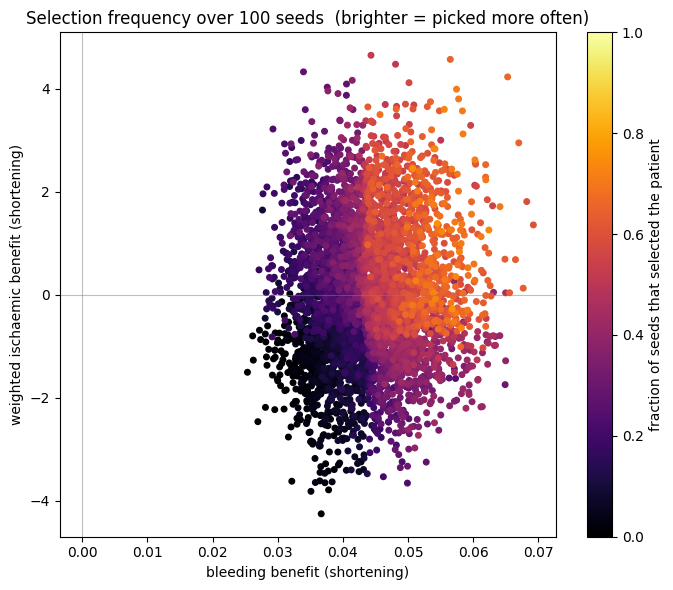

100 seeds, 1500 selected each   mean freq=0.33
always picked (freq=1): 0   never picked (freq=0): 72


In [ ]:
# --- Selection frequency across many seeds: brighter = picked more often ---
# Re-run the SAME pairwise selection with different seeds (same #selected each time,
# 2289) and count how often each patient survives. Then colour every point on the
# trade-off plane by that frequency: the brighter it glows, the more consistently the
# algorithm enrols it.

N_SEEDS = 100

counts  = np.zeros(len(conflict))
for s in range(N_SEEDS):
    picks = select_pairwise(N_SELECT, np.random.default_rng(s))   # 2289 selected every seed
    counts[picks] += 1
freq = counts / N_SEEDS                       # 0..1 = share of seeds that selected the patient

order = np.argsort(freq)                       # dark/rarely-picked first, bright ones on top

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(C['bleed'][order], isch[order], c=freq[order], s=16, cmap='inferno',
                vmin=0, vmax=1)
ax.axhline(0, color='grey', lw=.8, alpha=.5); ax.axvline(0, color='grey', lw=.8, alpha=.5)
ax.set(xlabel='bleeding benefit (shortening)', ylabel='weighted ischaemic benefit (shortening)',
       title=f'Selection frequency over {N_SEEDS} seeds  (brighter = picked more often)')
fig.colorbar(sc, ax=ax, label='fraction of seeds that selected the patient')
plt.tight_layout(); plt.show()

print(f'{N_SEEDS} seeds, {len(picks)} selected each   mean freq={freq.mean():.2f}')
print(f'always picked (freq=1): {int((freq == 1).sum())}   never picked (freq=0): {int((freq == 0).sum())}')

In [ ]:
N_SEEDS = 100

conflict = conflict_from_model(cf, Xn, ENDPOINTS, ISCH_WEIGHTS, CF_TARGETS)

counts = np.zeros(len(conflict))
for s in range(N_SEEDS):
    picks = select_pairwise(N_SELECT, np.random.default_rng(s))
    counts[picks] += 1
freq = counts / N_SEEDS

# death is included in the selection (components_from_origin averages all three
# ischaemic endpoints, weighted by ISCH_WEIGHTS) but cannot be shown on this 2-D axis --
# the y-axis projects only mi and stroke (their relative ISCH_WEIGHTS) so the plane stays
# interpretable
mi_stroke_weights = {k: ISCH_WEIGHTS[k] for k in ('mi', 'stroke')}
isch  = weighted_isch({'mi': z(C['mi']), 'stroke': z(C['stroke'])}, mi_stroke_weights)
order = np.argsort(freq)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(C['bleed'][order], isch[order], c=freq[order], s=16, cmap='inferno',
                vmin=0, vmax=1)
ax.axhline(0, color='grey', lw=.8, alpha=.5)
ax.axvline(0, color='grey', lw=.8, alpha=.5)
ax.set(xlabel='bleeding benefit (shortening)',
       ylabel='ischaemic benefit — mi + stroke (death in selection, not shown)',
       title=f'Selection frequency over {N_SEEDS} seeds  (brighter = picked more often)')
fig.colorbar(sc, ax=ax, label='fraction of seeds that selected the patient')
plt.tight_layout()
plt.show()

print(f'{N_SEEDS} seeds, {len(picks)} selected each   mean freq={freq.mean():.2f}')
print(f'always picked (freq=1): {int((freq == 1).sum())}   never picked (freq=0): {int((freq == 0).sum())}')